# SQLDatabase를 이용한 Tool 생성
- SQLDatabase 도구를 사용하면 데이터베이스와 자연어로 상호작용할 수 있습니다. 초보자도 쉽게 따라할 수 있는 예제를 만들어보겠습니다.


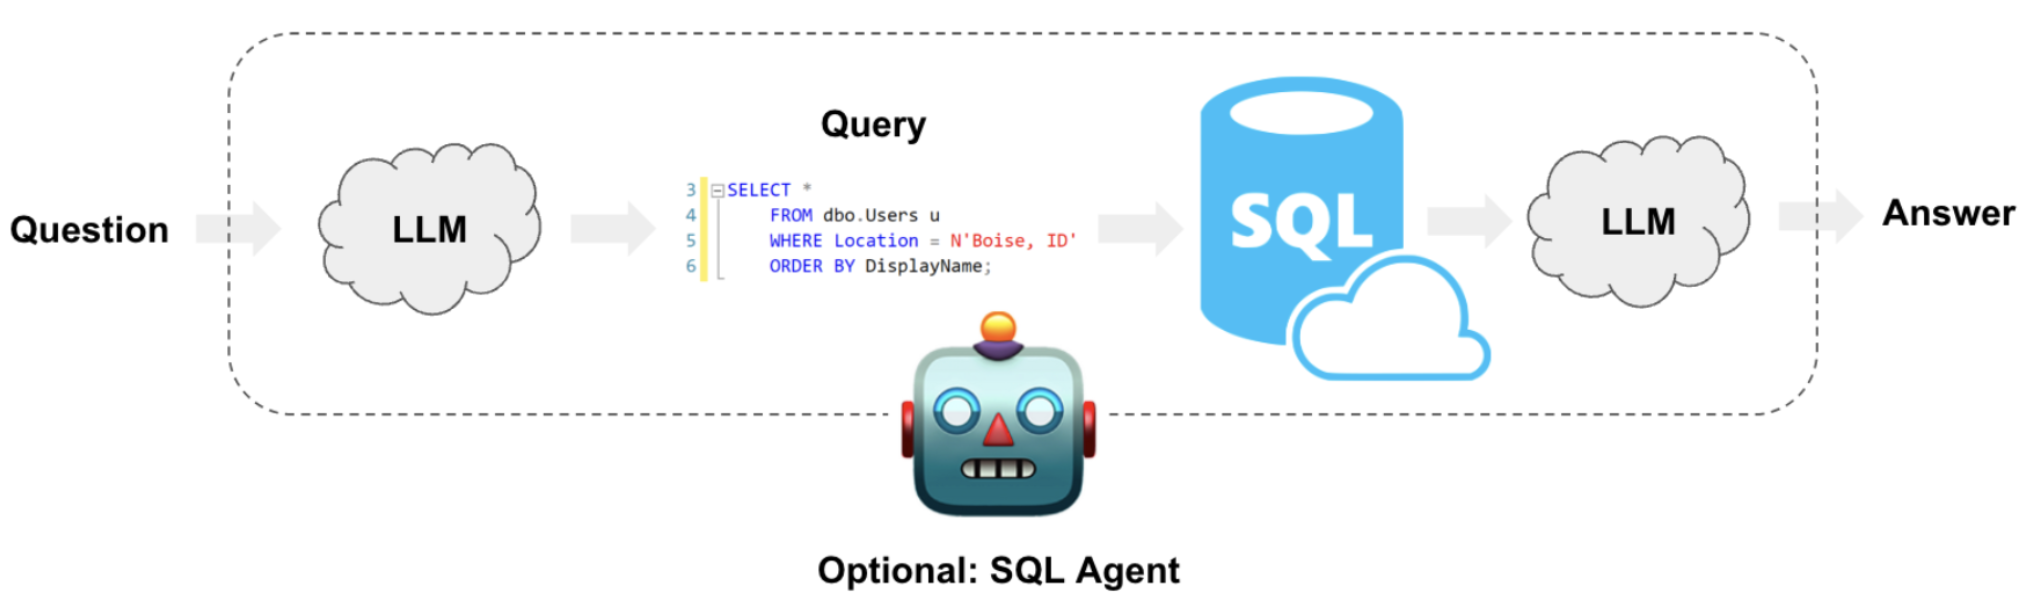


### 핵심 포인트:
1. **자연어 쿼리**: SQL을 몰라도 자연어로 데이터베이스 조회 가능
2. **안전한 접근**: 도구를 통해 안전하게 데이터베이스에 접근
3. **복합 분석**: 여러 테이블을 조인하여 복잡한 분석 수행
4. **LCEL 통합**: 다른 도구들과 연계하여 종합적인 데이터 분석


### 주의사항:
- 실제 운영 데이터베이스 사용시 읽기 전용 권한 권장
- 민감한 데이터는 별도 보안 조치 필요
- 대용량 데이터베이스의 경우 쿼리 최적화 고려


## QuerySQLDatabaseTool vs SQLDatabaseToolkit

| 구분    | QuerySQLDatabaseTool | SQLDatabaseToolkit           |
| ----- | -------------------- | ---------------------------- |
| 역할    | SQL 실행기 (단일 기능)      | SQL 관련 도구 모음 (복합 기능)         |
| 입력    | 완성된 SQL 쿼리           | 자연어 질문 또는 에이전트 액션            |
| 내부 기능 | 단순 실행만 함             | 테이블 정보, 스키마 확인, 쿼리 검증, 실행 등  |
| 복잡도   | 간단함                  | 조금 더 설정이 필요함                 |
| 사용 목적 | 이미 SQL 쿼리를 알고 있을 때   | LLM이 SQL을 자동으로 작성하고 실행하게 할 때 |
| 구성 요소 | 단일 도구                | 여러 도구(4~5개)로 구성됨             |


# 예시

## 1단계: 간단한 SQLite 데이터베이스 생성

In [28]:
import sqlite3

def create_sample_database():
    """학습용 샘플 데이터베이스를 생성합니다."""
    
    # SQLite 데이터베이스 생성
    conn = sqlite3.connect('sample_company.db')
    cursor = conn.cursor()
    
    # 직원 테이블 생성
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS employees (
            id INTEGER PRIMARY KEY,
            name TEXT NOT NULL,
            department TEXT NOT NULL,
            salary INTEGER NOT NULL,
            hire_date TEXT NOT NULL
        )
    ''')
    
    # 부서 테이블 생성
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS departments (
            id INTEGER PRIMARY KEY,
            dept_name TEXT NOT NULL,
            manager TEXT NOT NULL,
            budget INTEGER NOT NULL
        )
    ''')
    
    # 샘플 데이터 삽입 - 직원
    employees_data = [
        (1, '김철수', 'IT', 5000, '2020-01-15'),
        (2, '이영희', 'HR', 4500, '2019-03-20'),
        (3, '박민수', 'IT', 5500, '2021-07-10'),
        (4, '최지영', 'Sales', 4000, '2020-09-05'),
        (5, '정수현', 'Marketing', 4200, '2022-01-25')
    ]
    
    cursor.executemany('INSERT OR REPLACE INTO employees VALUES (?, ?, ?, ?, ?)', employees_data)
    
    # 샘플 데이터 삽입 - 부서
    departments_data = [
        (1, 'IT', '김철수', 100000),
        (2, 'HR', '이영희', 50000),
        (3, 'Sales', '최지영', 80000),
        (4, 'Marketing', '정수현', 60000)
    ]
    
    cursor.executemany('INSERT OR REPLACE INTO departments VALUES (?, ?, ?, ?)', departments_data)
    
    conn.commit()
    conn.close()
    print("샘플 데이터베이스가 생성되었습니다!")

In [29]:
# 데이터베이스 생성 실행
create_sample_database()

샘플 데이터베이스가 생성되었습니다!


### 데이터베이스 확인

> SQLite3 Editor 설치

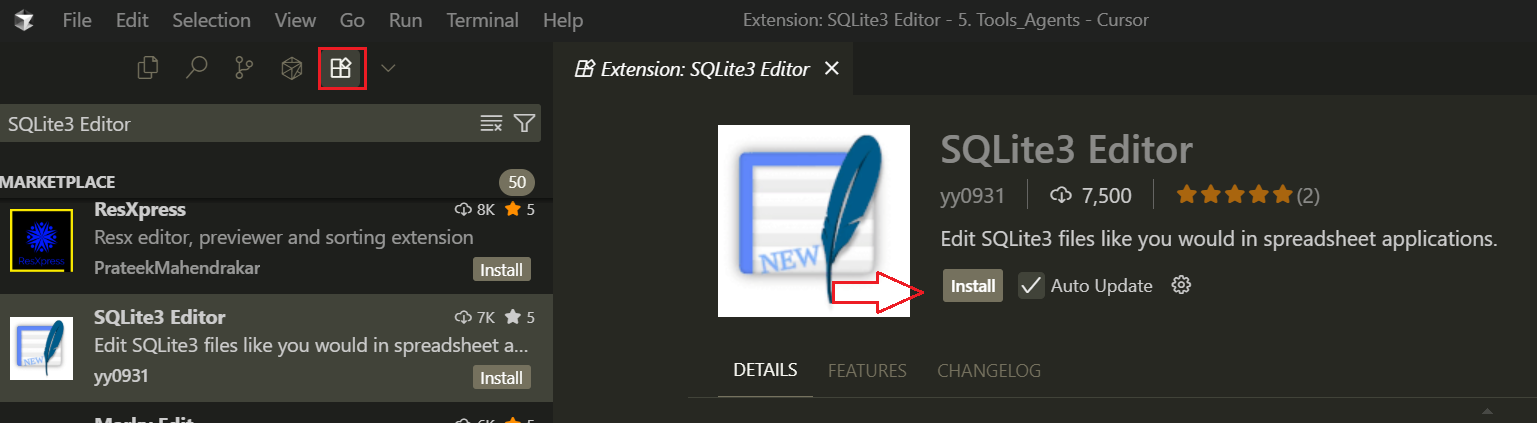

> 저장된 데이터 확인

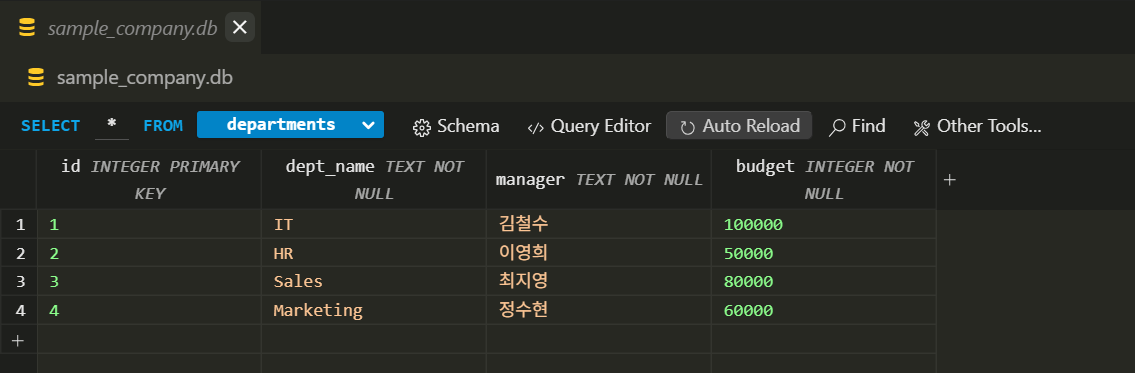

## 2단계: SQLDatabase 연결

In [30]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///sample_company.db")

In [31]:
# 전체 직원의 수 
result = db.run("SELECT COUNT(*) as total_employees FROM employees")

result

'[(5,)]'

> ast.literal_eval()는 문자열 형태의 파이썬 리터럴(literal)을 "안전하게" 실제 파이썬 객체로 변환하는 함수 입니다.

In [32]:
import ast

lst_result = ast.literal_eval(result)
lst_result[0][0]

5

## 3단계: SQL 도구 생성

In [33]:
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool

sql_tool = QuerySQLDatabaseTool(db=db)

In [34]:
result = sql_tool.invoke("SELECT COUNT(*) as total_employees FROM employees")

result

'[(5,)]'

## 4단계: 커스텀 데이터베이스 도구들 생성

In [35]:
from langchain.tools import tool
import ast

@tool
def get_employee_count() -> str:
    """전체 직원 수를 조회합니다."""
    try:
        result = sql_tool.invoke("SELECT COUNT(*) as total_employees FROM employees")
        return f"현재 총 직원 수: {ast.literal_eval(result)[0][0]}명"
    except Exception as e:
        return f"직원 수 조회 중 오류가 발생했습니다: {str(e)}"

In [36]:
get_employee_count.invoke("")

'현재 총 직원 수: 5명'

In [37]:
@tool
def get_department_summary() -> str:
    """부서별 직원 수와 평균 급여를 조회합니다."""
    try:
        query = """
        SELECT 
            department,
            COUNT(*) as employee_count,
            AVG(salary) as avg_salary,
            MAX(salary) as max_salary,
            MIN(salary) as min_salary
        FROM employees 
        GROUP BY department
        ORDER BY employee_count DESC
        """
        result = sql_tool.invoke(query)
        return f"부서별 통계:\n{ast.literal_eval(result)}"
    except Exception as e:
        return f"부서별 통계 조회 중 오류가 발생했습니다: {str(e)}"

In [38]:
print(get_department_summary.invoke(""))

부서별 통계:
[('IT', 2, 5250.0, 5500, 5000), ('Sales', 1, 4000.0, 4000, 4000), ('Marketing', 1, 4200.0, 4200, 4200), ('HR', 1, 4500.0, 4500, 4500)]


In [39]:
@tool
def get_high_salary_employees(salary_threshold: int = 5000) -> str:
    """지정된 급여 이상의 직원들을 조회합니다."""
    try:
        query = f"""
        SELECT name, department, salary, hire_date 
        FROM employees 
        WHERE salary >= {salary_threshold}
        ORDER BY salary DESC
        """
        result = sql_tool.invoke(query)
        return f"급여 {salary_threshold}만원 이상 직원:\n{ast.literal_eval(result)}"
    except Exception as e:
        return f"고급여 직원 조회 중 오류가 발생했습니다: {str(e)}"

In [40]:
high_salary_employees_result = get_high_salary_employees.invoke({
    "salary_threshold":5000
})

In [41]:
print(high_salary_employees_result)

급여 5000만원 이상 직원:
[('박민수', 'IT', 5500, '2021-07-10'), ('김철수', 'IT', 5000, '2020-01-15')]


In [42]:
@tool
def search_employee_by_name(name: str) -> str:
    """이름으로 직원을 검색합니다."""
    try:
        query = f"""
        SELECT e.name, e.department, e.salary, e.hire_date, d.manager, d.budget
        FROM employees e
        LEFT JOIN departments d ON e.department = d.dept_name
        WHERE e.name LIKE '%{name}%'
        """
        result = sql_tool.invoke(query)
        if result:
            return f"'{name}' 검색 결과:\n{ast.literal_eval(result)}"
        else:
            return f"'{name}'과 일치하는 직원을 찾을 수 없습니다."
    except Exception as e:
        return f"직원 검색 중 오류가 발생했습니다: {str(e)}"

In [43]:
employee_result = search_employee_by_name.invoke({
    "name":"김철수"
})

print(employee_result)

'김철수' 검색 결과:
[('김철수', 'IT', 5000, '2020-01-15', '김철수', 100000)]


## 5단계: LLM과 에이전트 설정

### LLM

In [44]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

In [45]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### tools

In [46]:

tools = [sql_tool, get_employee_count, get_department_summary, get_high_salary_employees, search_employee_by_name]

In [47]:
for tool in tools:
    print("=" * 50)
    print(f"Tool 이름: {tool.name}")
    print(f"Tool 설명: {tool.description}")
    print(f"Tool 인풋 파라미터: {tool.args}")
    print(f"Tool return_direct: {tool.return_direct}")

Tool 이름: sql_db_query
Tool 설명: 
    Execute a SQL query against the database and get back the result..
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again.
    
Tool 인풋 파라미터: {'query': {'description': 'A detailed and correct SQL query.', 'title': 'Query', 'type': 'string'}}
Tool return_direct: False
Tool 이름: get_employee_count
Tool 설명: 전체 직원 수를 조회합니다.
Tool 인풋 파라미터: {}
Tool return_direct: False
Tool 이름: get_department_summary
Tool 설명: 부서별 직원 수와 평균 급여를 조회합니다.
Tool 인풋 파라미터: {}
Tool return_direct: False
Tool 이름: get_high_salary_employees
Tool 설명: 지정된 급여 이상의 직원들을 조회합니다.
Tool 인풋 파라미터: {'salary_threshold': {'default': 5000, 'title': 'Salary Threshold', 'type': 'integer'}}
Tool return_direct: False
Tool 이름: search_employee_by_name
Tool 설명: 이름으로 직원을 검색합니다.
Tool 인풋 파라미터: {'name': {'title': 'Name', 'type': 'string'}}
Tool return_direct: False


### Agent

In [48]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="""
    당신은 주어진 도구를 반드시 사용해서만 답변해야 하는 AI 어시스턴트입니다.
    절대로 자신의 지식으로 직접 답변하지 마세요.
    모든 최종 답변은 반드시 도구의 출력 결과를 기반으로 해야 합니다.
    """
)

## 6단계: 데이터베이스 질의 테스트

### 기본 통계 조회

In [49]:
from langchain_core.messages import HumanMessage

user_input = "우리 회사의 총 직원 수와 부서별 통계를 알려주세요."
result1 = agent.invoke(
    {"messages": HumanMessage(content=user_input)}
)

In [50]:
print(result1['messages'][-1].content)

다음과 같이 확인되었습니다.

- 현재 총 직원 수: 5명

- 부서별 통계
  - IT: 직원 수 2명, 평균 급여 5250.0, 최고 급여 5500, 최저 급여 5000
  - Sales: 직원 수 1명, 평균 급여 4000.0, 최고 급여 4000, 최저 급여 4000
  - Marketing: 직원 수 1명, 평균 급여 4200.0, 최고 급여 4200, 최저 급여 4200
  - HR: 직원 수 1명, 평균 급여 4500.0, 최고 급여 4500, 최저 급여 4500


### 특정 조건 검색

In [51]:
from langchain_core.messages import HumanMessage

user_input = "급여가 5000만원 이상인 직원들의 정보를 알려주세요."
result2 = agent.invoke(
    {"messages": HumanMessage(content=user_input)}
)

In [52]:
print(result2['messages'][-1].content)

다음과 같습니다.

- 박민수 | 부서: IT | 급여: 5500만원 | 입사일: 2021-07-10
- 김철수 | 부서: IT | 급여: 5000만원 | 입사일: 2020-01-15


### 이름 검색

In [53]:
from langchain_core.messages import HumanMessage

user_input = "김철수 직원의 상세 정보를 조회해주세요."
result3 = agent.invoke(
    {"messages": HumanMessage(content=user_input)}
)

In [54]:
print(result3['messages'][-1].content)

다음은 김철수 직원의 조회 결과에 따른 상세 정보입니다.

- 이름: 김철수
- 부서: IT
- 급여: 5000
- 입사일: 2020-01-15
- 표시 이름: 김철수
- 직원 ID: 100000

원하시면 이메일, 전화번호 등 추가 항목도 조회해 드리겠습니다. 어떤 정보를 더 확인하고 싶으신가요?


## [Langsmith에서 확인하기](https://smith.langchain.com/)

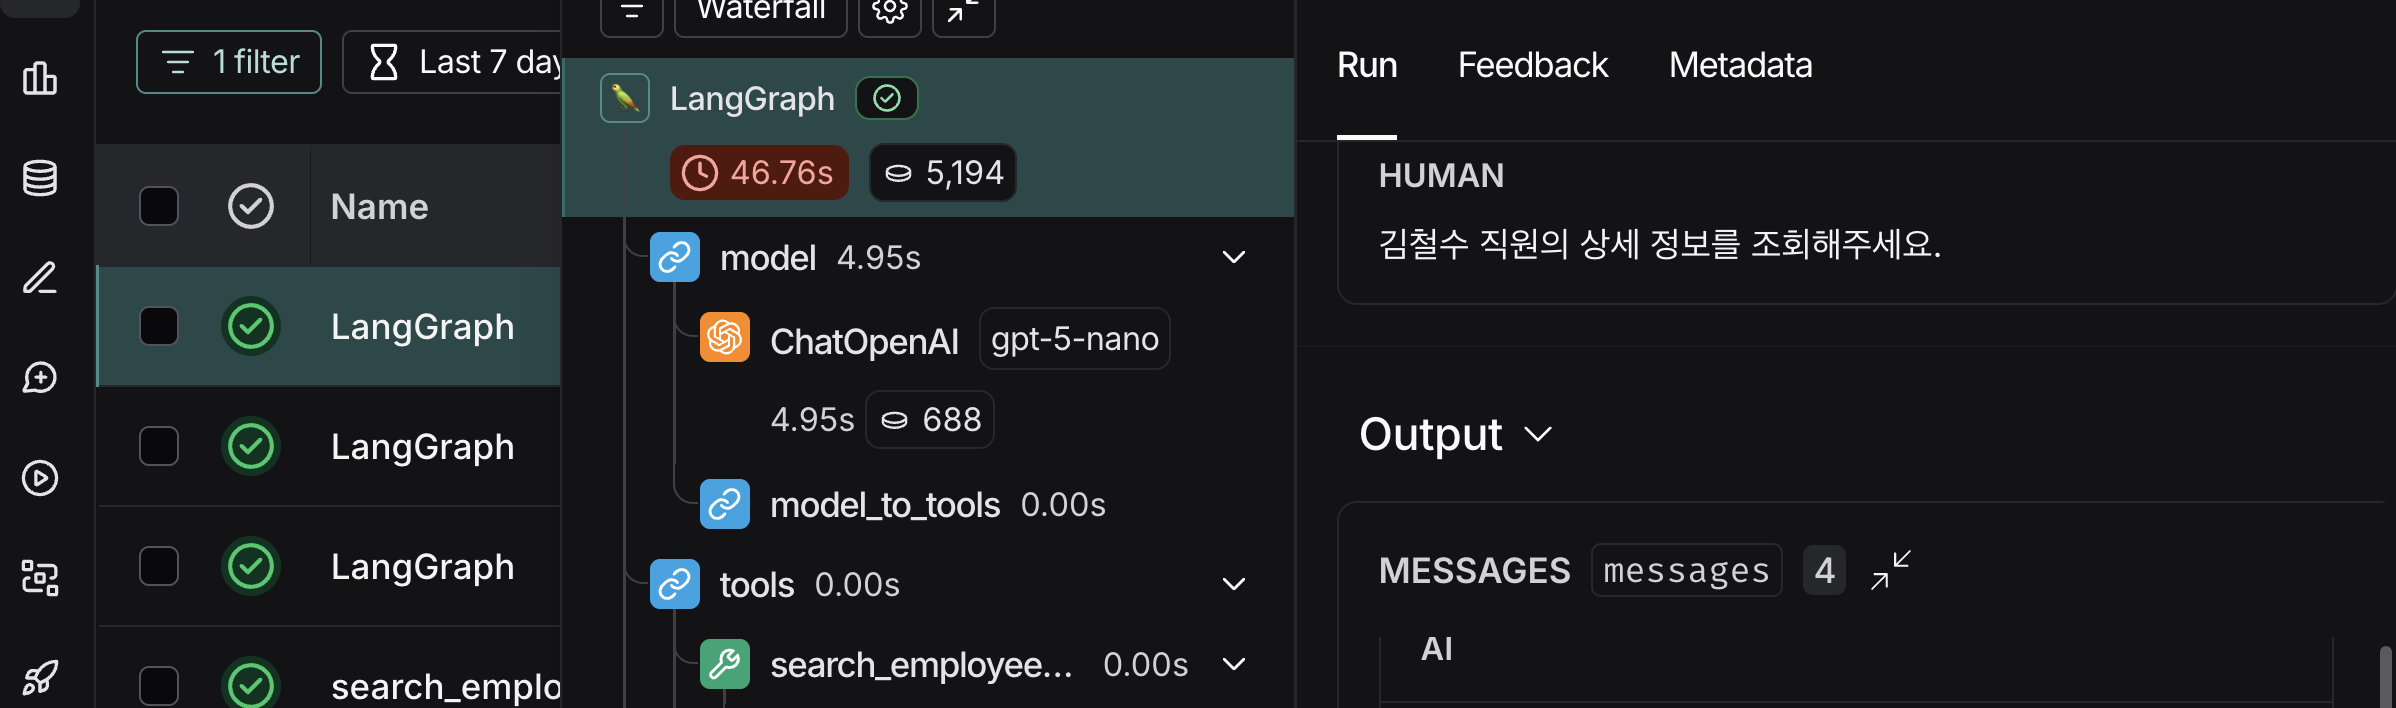